# Ejercicio 1: Detección de Fraude de Tarjetas de Crédito
Modelo de clasificación binaria usando Random Forest.

Distribución de clases (0 = Normal, 1 = Fraude):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


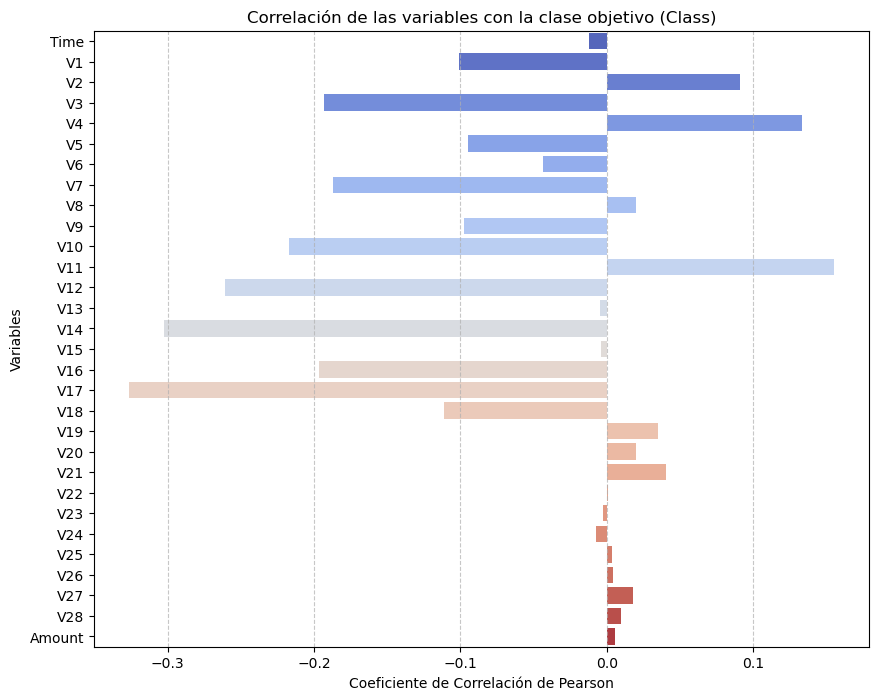

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datos
df_fraud = pd.read_csv('creditcard.csv')

print("Distribución de clases (0 = Normal, 1 = Fraude):")
print(df_fraud['Class'].value_counts(normalize=True) * 100)

# Matriz de correlación respecto a la variable objetivo
plt.figure(figsize=(10, 8))
corr_fraud = df_fraud.corr()

valores_corr = corr_fraud['Class'].drop('Class')
sns.barplot(x=valores_corr.values, 
            y=valores_corr.index, 
            hue=valores_corr.index,
            legend=False,
            palette='coolwarm')

plt.title('Correlación de las variables con la clase objetivo (Class)')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Variables')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

# Descarte de variables con correlación inferior a 0.05
umbral = 0.05
vars_relevantes = corr_fraud[abs(corr_fraud['Class']) > umbral].index.tolist()
vars_relevantes.remove('Class')

X_fraud = df_fraud[vars_relevantes]
y_fraud = df_fraud['Class']

# División estratificada
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.80      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



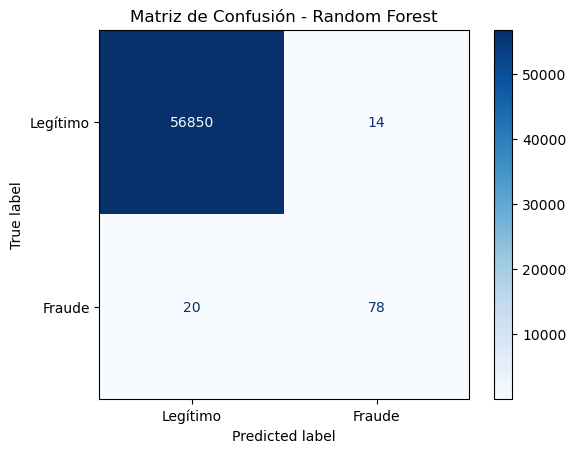

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Entrenamiento con class_weight para mitigar el desbalanceo
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=15, 
    class_weight='balanced', 
    n_jobs=-1, 
    random_state=42
)
rf_model.fit(X_train_f, y_train_f)

# Predicción y evaluación
y_pred_f = rf_model.predict(X_test_f)
print(classification_report(y_test_f, y_pred_f))

cm = confusion_matrix(y_test_f, y_pred_f)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legítimo', 'Fraude'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

# Ejercicio 2: Predicción de Precios de Vivienda en California
Modelo de regresión usando Support Vector Machines (SVR).

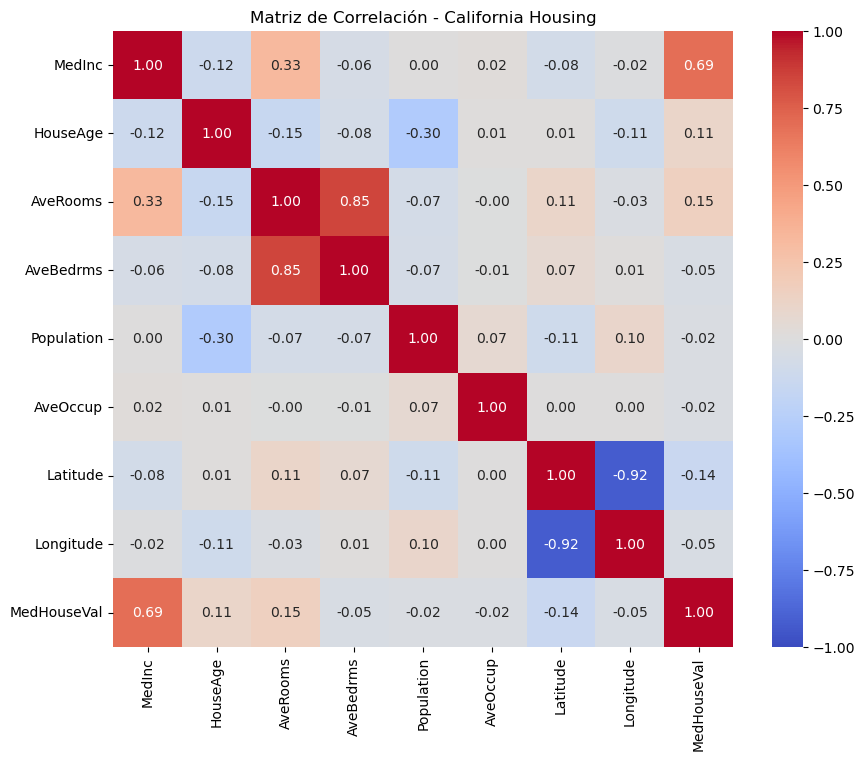

In [5]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing(as_frame=True)
df_cal = california.frame

# Mapa de calor de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df_cal.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación - California Housing')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Descarte de AveBedrms por multicolinealidad extrema con AveRooms
X_cal = df_cal.drop(columns=['MedHouseVal', 'AveBedrms'])
y_cal = df_cal['MedHouseVal']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cal, y_cal, test_size=0.2, random_state=42
)

# Submuestreo para evitar cuellos de botella en SVM (O(n^3))
X_train_c_sub = X_train_c.sample(n=5000, random_state=42)
y_train_c_sub = y_train_c.loc[X_train_c_sub.index]

# Escalado de datos 
scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c_sub)
X_test_c_scaled = scaler.transform(X_test_c)

Error Cuadrático Medio (MSE): 0.4158
Coeficiente de Determinación (R2): 0.6827


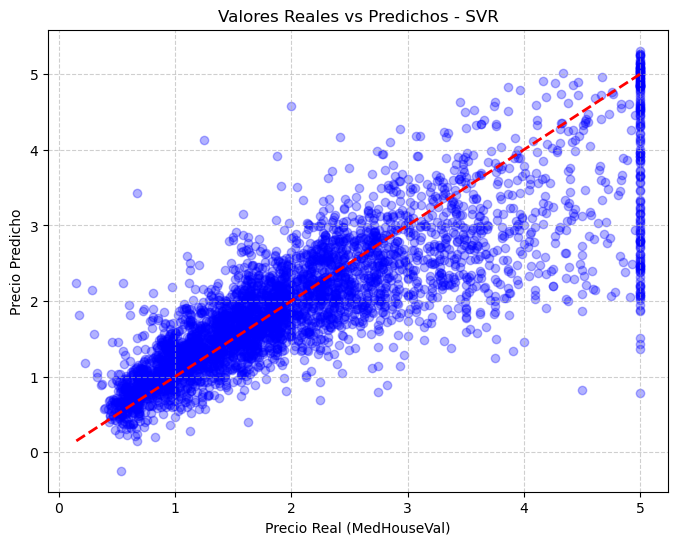

In [7]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Entrenamiento SVR con kernel RBF
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(X_train_c_scaled, y_train_c_sub)

# Predicción y evaluación
y_pred_c = svr_model.predict(X_test_c_scaled)

mse = mean_squared_error(y_test_c, y_pred_c)
r2 = r2_score(y_test_c, y_pred_c)

print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Coeficiente de Determinación (R2): {r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_c, y_pred_c, alpha=0.3, color='blue')
plt.plot([y_test_c.min(), y_test_c.max()], [y_test_c.min(), y_test_c.max()], 'r--', lw=2)
plt.title('Valores Reales vs Predichos - SVR')
plt.xlabel('Precio Real (MedHouseVal)')
plt.ylabel('Precio Predicho')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()